<a href="https://colab.research.google.com/github/shhjosh02/Financial-Forecast-ML/blob/main/notebooks/02_Modelos_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✅ Colab conectado. Directorio actual: /content/drive/MyDrive/Proyecto_IA/notebooks
✅ Dataset cargado: 18693 filas

📊 BALANCE DE CLASES
Label
1    10286
0     8407
Name: count, dtype: int64

Porcentaje:
Label
1    55.025946
0    44.974054
Name: proportion, dtype: float64

✅ Train: 14954 | Test: 3739

⚖️ Class weights: {0: np.float64(1.1070476754515843), 1: np.float64(0.911829268292683)}

📊 ENTRENANDO REGRESIÓN LOGÍSTICA
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

🌲 ENTRENANDO RANDOM FOREST
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

🚀 ENTRENANDO RED NEURONAL PYTORCH (MLP)
Accuracy:  0.9957
Precision: 1.0000
Recall:    0.9923
F1-Score:  0.9962
ROC-AUC:   0.9999

📊 GRÁFICO: MATRICES DE CONFUSIÓN COMPARATIVAS


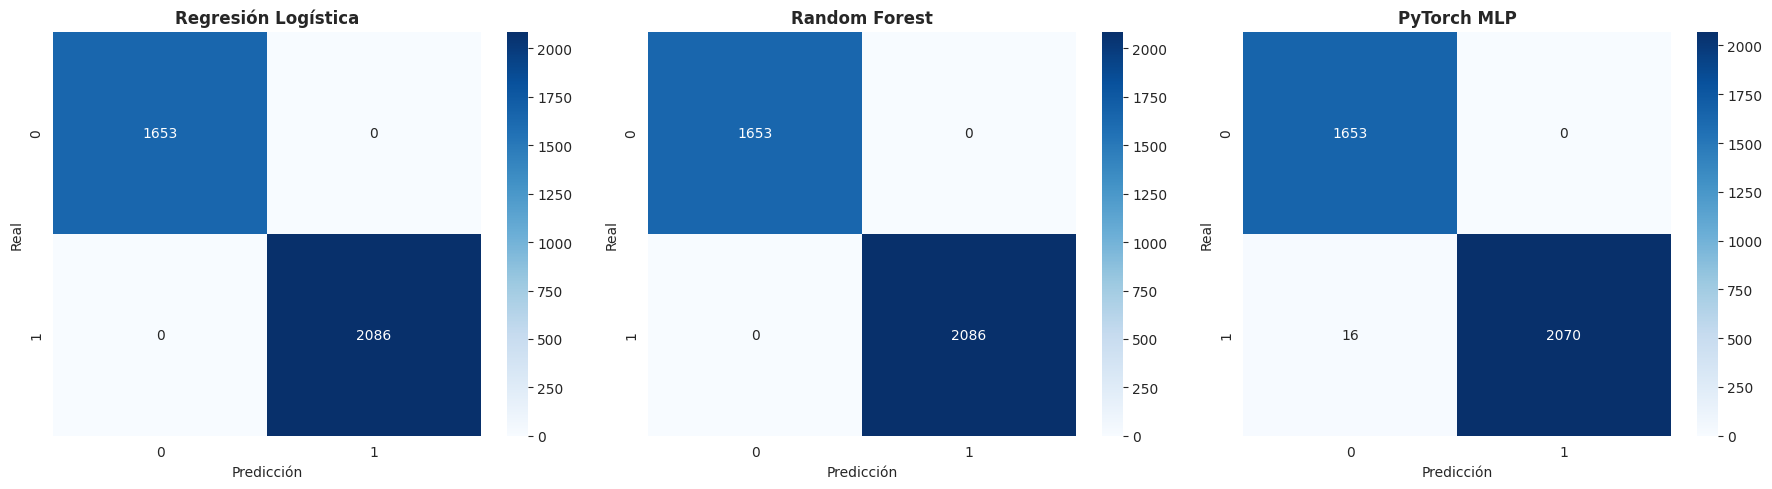


✅ Evaluación de modelos completada con éxito.


In [1]:
# =========================================================
# BLOQUE DE PORTABILIDAD: Colab + Drive + Local
# =========================================================
import os
import sys

EN_COLAB = 'google.colab' in sys.modules
CARPETA_DRIVE = 'Proyecto_IA'

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir(f'/content/drive/MyDrive/{CARPETA_DRIVE}/notebooks')
    print(f"✅ Colab conectado. Directorio actual: {os.getcwd()}")

os.makedirs('../outputs/graficos', exist_ok=True)

# -*- coding: utf-8 -*-
"""
MODELOS DE MACHINE LEARNING (CORREGIDO)
FASE 2: ENTRENAMIENTO, EVALUACIÓN Y MATRICES DE CONFUSIÓN
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack, csr_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# =========================================================
# 2. CARGAR DATOS PROCESADOS
# =========================================================
df = pd.read_csv('../data/dataset_procesado.csv', sep=';', encoding='latin-1')
print(f"✅ Dataset cargado: {df.shape[0]} filas")

# Verificar balance de clases
print("\n" + "="*60)
print("📊 BALANCE DE CLASES")
print("="*60)
print(df['Label'].value_counts())
print(f"\nPorcentaje:")
print(df['Label'].value_counts(normalize=True) * 100)

# =========================================================
# 3. PREPARAR CARACTERÍSTICAS
# =========================================================
features_num = ['daily_return', 'intraday_volatility', 'volume_scaled', 'price_range']
X_num = df[features_num].fillna(0).values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

tfidf = TfidfVectorizer(max_features=500, stop_words=None)
X_text = tfidf.fit_transform(df['text_clean'].fillna('').values)

X_combined = hstack([csr_matrix(X_num_scaled), X_text])
y = df['Label'].values

# =========================================================
# 4. DIVIDIR DATOS CRONOLÓGICAMENTE (CORRECCIÓN 1)
# =========================================================
split_idx = int(len(df) * 0.8)

X_train = X_combined[:split_idx]
X_test = X_combined[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"\n✅ Train: {len(y_train)} | Test: {len(y_test)}")

# Calcular class weights (CORRECCIÓN 2)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"\n⚖️ Class weights: {class_weight_dict}")

# =========================================================
# 5. REGRESIÓN LOGÍSTICA
# =========================================================
print("\n" + "="*60)
print("📊 ENTRENANDO REGRESIÓN LOGÍSTICA")
print("="*60)
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_log, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_log, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_log):.4f}")

# =========================================================
# 6. RANDOM FOREST
# =========================================================
print("\n" + "="*60)
print("🌲 ENTRENANDO RANDOM FOREST")
print("="*60)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

# =========================================================
# 7. PYTORCH MLP (CORRECCIÓN 3: dividir cronológicamente)
# =========================================================
X_num_train = X_num_scaled[:split_idx]
X_num_test = X_num_scaled[split_idx:]

X_train_t = torch.tensor(X_num_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_num_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, len(np.unique(y)))
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)  # Más dropout

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

model_pt = MLPClassifier(input_dim=X_num_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)
loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

print("\n" + "="*60)
print("🚀 ENTRENANDO RED NEURONAL PYTORCH (MLP)")
print("="*60)
for epoch in range(30):
    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        loss = criterion(model_pt(batch_X), batch_y)
        loss.backward()
        optimizer.step()

with torch.no_grad():
    _, predicted = torch.max(model_pt(X_test_t), 1)
    acc_pt = (predicted == y_test_t).float().mean().item()
    y_pred_pt = predicted.numpy()

# Calcular probabilidades para ROC-AUC
with torch.no_grad():
    probs_pt = torch.softmax(model_pt(X_test_t), dim=1)[:, 1].numpy()

print(f"Accuracy:  {accuracy_score(y_test, y_pred_pt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_pt, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_pt, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_pt, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, probs_pt):.4f}")

# =========================================================
# 8. GRÁFICO: MATRICES DE CONFUSIÓN COMPARATIVAS
# =========================================================
print("\n" + "="*75)
print("📊 GRÁFICO: MATRICES DE CONFUSIÓN COMPARATIVAS")
print("="*75)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_dict = {
    'Regresión Logística': y_pred_log,
    'Random Forest': y_pred_rf,
    'PyTorch MLP': y_pred_pt
}

for i, (name, preds) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=True)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.savefig('../outputs/graficos/matrices_confusion_comparativa.png', dpi=300)
plt.show()

print("\n✅ Evaluación de modelos completada con éxito.")